  PASO 1: Cargando dataset...
  → Registros totales: 27,051

  PASO 2: Limpiando precio...
  → Precios válidos: 23,567

  PASO 3: Limpiando baños...
  → Baños válidos: 27,030

  PASO 4: Preparando 6 features...
  → Registros antes:  27,051
  → Registros después: 23,435
  → Eliminados:       3,616
  → Registros finales: 23,200
  → Rango de precios: $61 - $9,906 MXN

  Estadísticas:
       capacidad  habitaciones     banos     camas   latitud  longitud    precio
count   23200.00      23200.00  23200.00  23200.00  23200.00  23200.00  23200.00
mean        3.33          1.50      1.42      1.91     19.41    -99.17   1338.46
std         2.23          1.07      0.94      1.59      0.04      0.03   1158.83
min         1.00          0.00      0.00      0.00     19.18    -99.34     61.00
25%         2.00          1.00      1.00      1.00     19.40    -99.18    642.75
50%         2.00          1.00      1.00      1.00     19.42    -99.17   1034.00
75%         4.00          2.00      2.00      2.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)


  Entrenando (max 300 epochs, early stopping activado)...
Epoch 1/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1552591.5000 - mae: 788.5258 - val_loss: 955369.9375 - val_mae: 590.7053 - learning_rate: 0.0010
Epoch 2/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1009236.7500 - mae: 594.2166 - val_loss: 898180.2500 - val_mae: 580.9548 - learning_rate: 0.0010
Epoch 3/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 935175.0625 - mae: 589.6085 - val_loss: 882636.2500 - val_mae: 567.6771 - learning_rate: 0.0010
Epoch 4/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 918083.8750 - mae: 586.1862 - val_loss: 876529.5625 - val_mae: 575.0920 - learning_rate: 0.0010
Epoch 5/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 901240.6875 - mae: 583.8591 - val_loss: 877476.6250 - val_mae: 550.3038 - learning_rate: 0.0010
Epoch 6/300
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 897588.5625 - mae: 581.6314 - val_loss: 857699.8750 - val_mae: 556.1674 - learning_rate: 0.00

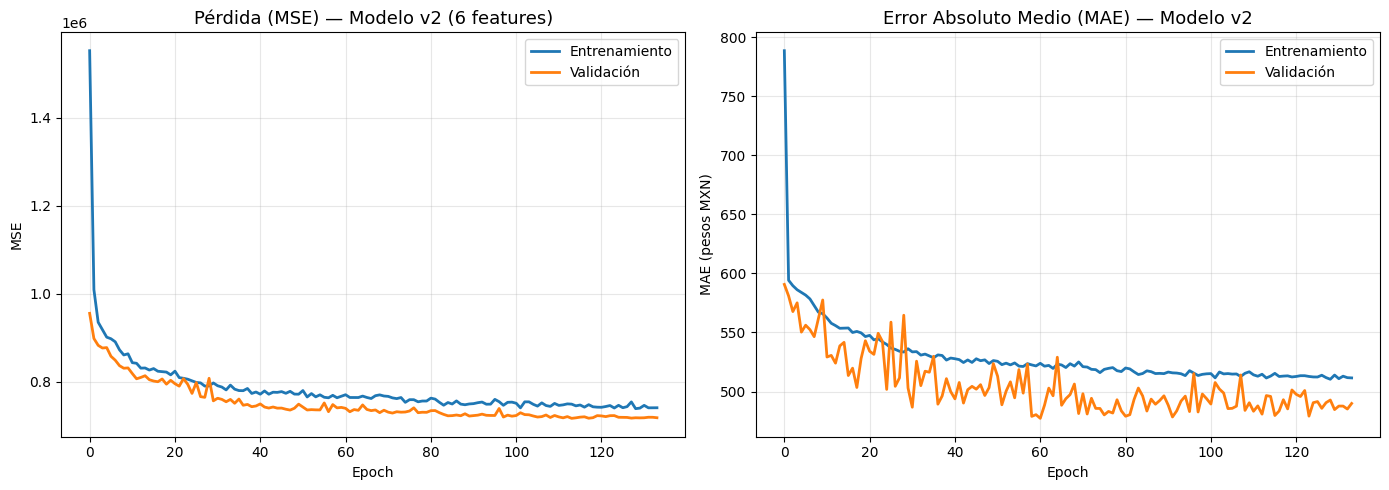

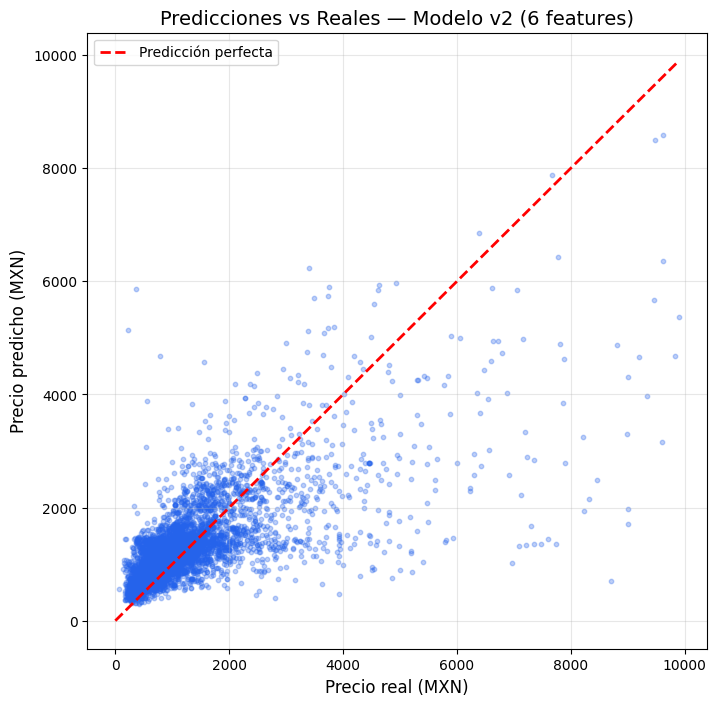

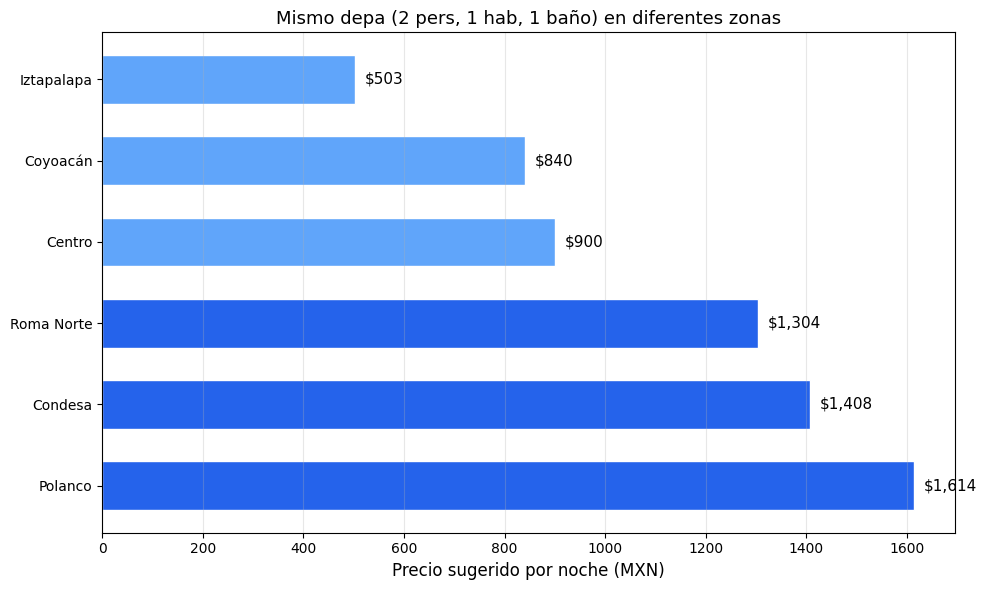

In [1]:
"""
=============================================================
  RED NEURONAL v2 - PREDICCIÓN DE PRECIOS AIRBNB CDMX
  Ahora con 6 features: capacidad, habitaciones, baños,
                         camas, latitud, longitud
=============================================================

Instrucciones:
1. Coloca "listings.csv.gz" en la MISMA carpeta que este script
2. Ejecuta: python entrenar_modelo_v2.py
3. El modelo se guardará como "modelo_precios_v2.keras"

Requisitos:
  pip install tensorflow pandas numpy scikit-learn matplotlib
"""

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re

# ─────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────
RUTA_ARCHIVO = "listings.csv.gz"
EPOCHS = 300
LEARNING_RATE = 0.001
BATCH_SIZE = 32


# ─────────────────────────────────────────────
# PASO 1: CARGAR DATOS
# ─────────────────────────────────────────────
print("=" * 60)
print("  PASO 1: Cargando dataset...")
print("=" * 60)

df = pd.read_csv(RUTA_ARCHIVO, low_memory=False)
print(f"  → Registros totales: {len(df):,}")


# ─────────────────────────────────────────────
# PASO 2: LIMPIAR PRECIO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 2: Limpiando precio...")
print("=" * 60)

def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan
    texto = str(valor).replace("$", "").replace(",", "").strip()
    try:
        return float(texto)
    except ValueError:
        return np.nan

df["price_limpio"] = df["price"].apply(limpiar_precio)
print(f"  → Precios válidos: {df['price_limpio'].notna().sum():,}")


# ─────────────────────────────────────────────
# PASO 3: LIMPIAR BAÑOS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 3: Limpiando baños...")
print("=" * 60)

def limpiar_banos(row):
    if pd.notna(row.get("bathrooms")):
        try:
            return float(row["bathrooms"])
        except (ValueError, TypeError):
            pass
    texto = str(row.get("bathrooms_text", ""))
    if texto == "nan" or texto == "":
        return np.nan
    if "half" in texto.lower():
        return 0.5
    numeros = re.findall(r"[\d.]+", texto)
    if numeros:
        return float(numeros[0])
    return np.nan

df["bathrooms_limpio"] = df.apply(limpiar_banos, axis=1)
print(f"  → Baños válidos: {df['bathrooms_limpio'].notna().sum():,}")


# ─────────────────────────────────────────────
# PASO 4: PREPARAR LAS 6 FEATURES
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 4: Preparando 6 features...")
print("=" * 60)

# Seleccionar columnas
df_limpio = df[[
    "accommodates",      # Capacidad (personas)
    "bedrooms",          # Habitaciones
    "bathrooms_limpio",  # Baños (ya limpio)
    "beds",              # Camas
    "latitude",          # Latitud
    "longitude",         # Longitud
    "price_limpio"       # Precio (objetivo)
]].copy()

df_limpio.columns = [
    "capacidad", "habitaciones", "banos",
    "camas", "latitud", "longitud", "precio"
]

# Convertir todo a numérico
for col in df_limpio.columns:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")

# Eliminar nulos
antes = len(df_limpio)
df_limpio = df_limpio.dropna()
print(f"  → Registros antes:  {antes:,}")
print(f"  → Registros después: {len(df_limpio):,}")
print(f"  → Eliminados:       {antes - len(df_limpio):,}")

# Eliminar outliers de precio
precio_min = 1
precio_max = df_limpio["precio"].quantile(0.99)
df_limpio = df_limpio[
    (df_limpio["precio"] > precio_min) &
    (df_limpio["precio"] <= precio_max)
]

# Filtrar coordenadas razonables para CDMX
# (evita listings con coordenadas erróneas)
df_limpio = df_limpio[
    (df_limpio["latitud"] > 19.0) & (df_limpio["latitud"] < 19.8) &
    (df_limpio["longitud"] > -99.5) & (df_limpio["longitud"] < -98.8)
]

print(f"  → Registros finales: {len(df_limpio):,}")
print(f"  → Rango de precios: ${df_limpio['precio'].min():,.0f} - ${df_limpio['precio'].max():,.0f} MXN")

print("\n  Estadísticas:")
print(df_limpio.describe().round(2).to_string())


# ─────────────────────────────────────────────
# PASO 5: SEPARAR Y NORMALIZAR
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 5: Separando y normalizando datos...")
print("=" * 60)

FEATURES = ["capacidad", "habitaciones", "banos", "camas", "latitud", "longitud"]

X = df_limpio[FEATURES].values
y = df_limpio["precio"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

print(f"  → Features utilizados: {FEATURES}")
print(f"  → Entrenamiento: {len(X_train):,}")
print(f"  → Prueba:        {len(X_test):,}")
print(f"  → Input shape:   [{len(FEATURES)}]")


# ─────────────────────────────────────────────
# PASO 6: CONSTRUIR MODELO (más grande)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 6: Construyendo red neuronal v2...")
print("=" * 60)

modelo = tf.keras.Sequential([
    # Capa de entrada: 6 features
    tf.keras.layers.Dense(128, activation="relu", input_shape=[len(FEATURES)]),
    tf.keras.layers.Dropout(0.2),  # Evita overfitting

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.15),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(16, activation="relu"),

    # Salida: 1 valor (precio)
    tf.keras.layers.Dense(1)
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss="mean_squared_error",
    metrics=["mae"]
)

modelo.summary()

# Early stopping: detener si no mejora por 20 epochs seguidos
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# Reducir learning rate si se estanca
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

print(f"\n  Entrenando (max {EPOCHS} epochs, early stopping activado)...")
historial = modelo.fit(
    X_train_norm, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

epochs_reales = len(historial.history["loss"])
print(f"  ¡Entrenamiento completado en {epochs_reales} epochs!")


# ─────────────────────────────────────────────
# PASO 7: EVALUAR
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 7: Evaluando modelo v2...")
print("=" * 60)

loss, mae = modelo.evaluate(X_test_norm, y_test, verbose=0)
rmse = np.sqrt(loss)
print(f"  → MSE:  {loss:,.2f}")
print(f"  → RMSE: ${rmse:,.2f} MXN")
print(f"  → MAE:  ${mae:,.2f} MXN")
print(f"    (En promedio se equivoca por ~${mae:,.0f} pesos)")


# ─────────────────────────────────────────────
# PASO 8: PREDICCIONES DE EJEMPLO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 8: Predicciones de ejemplo...")
print("=" * 60)

# Coordenadas reales de zonas de CDMX
ZONAS = {
    "Condesa":    (19.4115, -99.1735),
    "Polanco":    (19.4320, -99.1980),
    "Coyoacán":   (19.3500, -99.1620),
    "Roma Norte": (19.4180, -99.1630),
    "Centro":     (19.4326, -99.1332),
    "Iztapalapa": (19.3550, -99.0900),
}

# [capacidad, habitaciones, baños, camas, latitud, longitud]
ejemplos = [
    {
        "datos": [2, 1, 1, 1, *ZONAS["Condesa"]],
        "desc": "Depa para 2, 1 hab, 1 baño, 1 cama — Condesa"
    },
    {
        "datos": [2, 1, 1, 1, *ZONAS["Iztapalapa"]],
        "desc": "Depa para 2, 1 hab, 1 baño, 1 cama — Iztapalapa"
    },
    {
        "datos": [4, 2, 1, 2, *ZONAS["Roma Norte"]],
        "desc": "Depa para 4, 2 habs, 1 baño, 2 camas — Roma Norte"
    },
    {
        "datos": [4, 2, 1, 2, *ZONAS["Iztapalapa"]],
        "desc": "Depa para 4, 2 habs, 1 baño, 2 camas — Iztapalapa"
    },
    {
        "datos": [6, 3, 2, 4, *ZONAS["Polanco"]],
        "desc": "Casa para 6, 3 habs, 2 baños, 4 camas — Polanco"
    },
    {
        "datos": [8, 4, 3, 5, *ZONAS["Coyoacán"]],
        "desc": "Casa para 8, 4 habs, 3 baños, 5 camas — Coyoacán"
    },
    {
        "datos": [3, 2, 1, 2, *ZONAS["Centro"]],
        "desc": "Tu ejemplo original: 3 pers, 2 hab, 1 baño — Centro"
    },
]

print(f"\n  {'Hospedaje':<55} {'Precio sugerido':>15}")
print("  " + "─" * 72)
for ej in ejemplos:
    entrada = np.array([ej["datos"]])
    entrada_norm = scaler.transform(entrada)
    precio = modelo.predict(entrada_norm, verbose=0)[0][0]
    print(f"  {ej['desc']:<55} ${max(precio, 0):>10,.0f} MXN")


# ─────────────────────────────────────────────
# PASO 9: GUARDAR TODO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 9: Guardando modelo y gráficas...")
print("=" * 60)

modelo.save("modelo_precios_v2.keras")
np.savez("scaler_params_v2.npz",
         mean=scaler.mean_,
         scale=scaler.scale_,
         feature_names=FEATURES)
print("  → Modelo guardado: modelo_precios_v2.keras")
print("  → Scaler guardado: scaler_params_v2.npz")

# --- Gráfica 1: Curvas de aprendizaje ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial.history["loss"], label="Entrenamiento", linewidth=2)
axes[0].plot(historial.history["val_loss"], label="Validación", linewidth=2)
axes[0].set_title("Pérdida (MSE) — Modelo v2 (6 features)", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial.history["mae"], label="Entrenamiento", linewidth=2)
axes[1].plot(historial.history["val_mae"], label="Validación", linewidth=2)
axes[1].set_title("Error Absoluto Medio (MAE) — Modelo v2", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (pesos MXN)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("grafica_entrenamiento_v2.png", dpi=150, bbox_inches="tight")
print("  → grafica_entrenamiento_v2.png")

# --- Gráfica 2: Predicciones vs Reales ---
y_pred = modelo.predict(X_test_norm, verbose=0).flatten()
fig2, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#2563EB")
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Predicción perfecta")
ax.set_xlabel("Precio real (MXN)", fontsize=12)
ax.set_ylabel("Precio predicho (MXN)", fontsize=12)
ax.set_title("Predicciones vs Reales — Modelo v2 (6 features)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("predicciones_vs_reales_v2.png", dpi=150, bbox_inches="tight")
print("  → predicciones_vs_reales_v2.png")

# --- Gráfica 3: Comparación por zona ---
fig3, ax3 = plt.subplots(figsize=(10, 6))
zonas_nombres = []
precios_zona = []
for zona, (lat, lon) in ZONAS.items():
    entrada = np.array([[2, 1, 1, 1, lat, lon]])
    entrada_norm = scaler.transform(entrada)
    precio = modelo.predict(entrada_norm, verbose=0)[0][0]
    zonas_nombres.append(zona)
    precios_zona.append(max(precio, 0))

# Ordenar de mayor a menor
orden = np.argsort(precios_zona)[::-1]
zonas_ord = [zonas_nombres[i] for i in orden]
precios_ord = [precios_zona[i] for i in orden]

colores = ["#2563EB" if p > np.median(precios_ord) else "#60A5FA" for p in precios_ord]
bars = ax3.barh(zonas_ord, precios_ord, color=colores, edgecolor="white", height=0.6)
ax3.set_xlabel("Precio sugerido por noche (MXN)", fontsize=12)
ax3.set_title("Mismo depa (2 pers, 1 hab, 1 baño) en diferentes zonas", fontsize=13)
for bar, precio in zip(bars, precios_ord):
    ax3.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f"${precio:,.0f}", va="center", fontsize=11)
ax3.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("comparacion_zonas_v2.png", dpi=150, bbox_inches="tight")
print("  → comparacion_zonas_v2.png")


print("\n" + "=" * 60)
print("  ¡MODELO v2 COMPLETADO!")
print("=" * 60)
print(f"""
  Resumen:
    Features:  {len(FEATURES)} ({', '.join(FEATURES)})
    Epochs:    {epochs_reales}
    MAE:       ~${mae:,.0f} MXN
    RMSE:      ~${rmse:,.0f} MXN

  Archivos generados:
    1. modelo_precios_v2.keras
    2. scaler_params_v2.npz
    3. grafica_entrenamiento_v2.png
    4. predicciones_vs_reales_v2.png
    5. comparacion_zonas_v2.png  ← ¡NUEVA! Compara zonas de CDMX

  Para usar después:
    modelo = tf.keras.models.load_model("modelo_precios_v2.keras")
    params = np.load("scaler_params_v2.npz")
    scaler = StandardScaler()
    scaler.mean_ = params["mean"]
    scaler.scale_ = params["scale"]

    # [capacidad, habitaciones, baños, camas, latitud, longitud]
    nuevo = np.array([[4, 2, 1, 2, 19.4115, -99.1735]])
    precio = modelo.predict(scaler.transform(nuevo))
""")